# Donor Retention Classifier
## End-to-End ML Pipeline · BrightHut / Lighthouse Sanctuary

---

## 1. Problem Framing

### Business Problem

BrightHut depends entirely on donor generosity to fund its safehouse operations. The organization's leadership has identified **donor retention** as one of its most pressing challenges: donors lapse without explanation, and limited staff make it difficult to maintain personalized outreach at scale. A donor who gives once and then disappears represents both a missed revenue opportunity and a relationship that could have been sustained with the right engagement at the right time.

**The business questions are:**
1. *Can we predict which active donors are at high risk of lapsing before they stop giving?* (Predictive)
2. *What factors most strongly drive donor churn, so the organization can design targeted retention interventions?* (Explanatory)

Donor churn is defined operationally as: **a supporter who made at least one monetary donation but has not donated in the 12 months prior to the analysis date.** This threshold is chosen because annual giving cycles are common among individual donors and aligns with the organization's yearly fundraising cadence.

### Who Cares About This

| Stakeholder | How they use this model |
|---|---|
| Executive Director | Understand overall retention health; allocate re-engagement budget |
| Fundraising/Outreach Staff | Get a ranked watchlist of at-risk donors to contact proactively |
| Program Staff | Connect donor engagement with safehouse outcomes to close the feedback loop |
| Data Analysts | Monitor model performance over time; retrain as new donations arrive |

### Prediction vs. Explanation — Explicit Choice

This pipeline delivers **both** a predictive model and an explanatory model, because the organization has two distinct and non-interchangeable needs:

- **Predictive goal:** Score each active donor on their probability of churning in the next 12 months. This score is served through an API endpoint and displayed on the admin dashboard as a ranked "at-risk donors" watchlist. Out-of-sample accuracy (ROC-AUC) is the primary success metric.

- **Explanatory goal:** Quantify which donor characteristics and behaviors are most causally associated with retention, so the organization can prioritize interventions (e.g., "donors who have not received a safehouse impact report in 6+ months are X% more likely to churn"). Here, interpretable coefficients and statistical defensibility matter more than marginal accuracy gains from ensemble complexity.

As the textbook warns: **confusing these goals is a common source of costly analytical mistakes.** We maintain two separate model objects — a logistic regression for explanation, and a gradient boosted tree for prediction — and interpret each only within its appropriate scope.

### Target Variable

**Binary classification:** `churned = 1` if the supporter's most recent donation was more than 365 days before the analysis reference date, `churned = 0` if they donated within the last 365 days.

Only supporters classified as monetary donors (`supporter_type` containing "Donor" or equivalent) with at least one recorded donation are included. Pure volunteers, skills contributors, and social media advocates without monetary giving history are excluded from this pipeline.

### Success Metrics

| Metric | Rationale |
|---|---|
| ROC-AUC (primary) | Class imbalance is likely; AUC measures discriminative power across all thresholds |
| Precision @ operating threshold | High-stakes outreach: staff time is limited, false positives waste resources |
| Recall @ operating threshold | Missing a churning donor is a real revenue loss |
| F1 score | Balanced view at the chosen operating threshold |

**Error cost asymmetry:** A false positive (contacting a retained donor unnecessarily) wastes modest outreach effort. A false negative (missing a churning donor) results in lost revenue and a broken relationship. **We tune the operating threshold to favor recall over precision** — it is better to over-contact than under-contact in a nonprofit retention context.

### Important Limitations

The dataset represents a sample of operations from a single organization. Sample sizes in the donor domain may be modest; results should be treated as directional and validated operationally before fully automating retention outreach. The model will be retrained quarterly as new donation data arrives.

---
## 2. Data Acquisition, Preparation & Exploration

In [1]:
# ── Install / import ─────────────────────────────────────────────────────────
# Uncomment the line below if running in a fresh Colab / minimal environment
!pip install scikit-learn pandas numpy matplotlib seaborn requests joblib -q --break-system-packages

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, GridSearchCV, train_test_split
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
import joblib
import json
import os

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')
print('All imports successful.')

All imports successful.


In [2]:
# ── Data Loading from local SQLite database ───────────────────────────────────
# Reads directly from the local brighthut.sqlite file — no network required.
# The database file lives at database/brighthut.sqlite relative to the repo root.
# Adjust DB_PATH below if you are running the notebook from a different location.

import sqlite3
import os

DB_PATH = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'database', 'brighthut.sqlite')
DB_PATH = os.path.normpath(DB_PATH)

if not os.path.exists(DB_PATH):
    raise FileNotFoundError(
        f"Database not found at {DB_PATH}\n"
        "Set DB_PATH to the absolute path of brighthut.sqlite on your machine."
    )

def load_table(name: str) -> pd.DataFrame:
    """Load an entire table from the local SQLite database."""
    with sqlite3.connect(DB_PATH) as conn:
        df = pd.read_sql_query(f"SELECT * FROM {name}", conn)
    print(f'  Loaded {name:<40s} → {df.shape[0]:>4d} rows × {df.shape[1]:>2d} cols')
    return df

print(f'Database: {DB_PATH}')

print('Loading tables...')
supporters          = load_table('supporters')
donations           = load_table('donations')
donation_allocations= load_table('donation_allocations')
in_kind_items       = load_table('in_kind_donation_items')
safehouses          = load_table('safehouses')
social_posts        = load_table('social_media_posts')
impact_snapshots    = load_table('public_impact_snapshots')
print('Done.')


Database: /Users/lincolnsteele/Desktop/IS Jr Core/INTEX2/BrightHut/database/brighthut.sqlite
Loading tables...
  Loaded supporters                               →   60 rows × 15 cols
  Loaded donations                                →  420 rows × 14 cols
  Loaded donation_allocations                     →  521 rows ×  7 cols
  Loaded in_kind_donation_items                   →  129 rows ×  9 cols
  Loaded safehouses                               →    9 rows × 13 cols
  Loaded social_media_posts                       →  812 rows × 39 cols
  Loaded public_impact_snapshots                  →   50 rows ×  7 cols
Done.


In [3]:
# ── Schema Inspection ─────────────────────────────────────────────────────────
print('=== supporters ===')
print(supporters.dtypes)
print(supporters.head(3).T)
print()
print('=== donations ===')
print(donations.dtypes)
print(donations.head(3).T)

=== supporters ===
supporter_id           int64
supporter_type           str
display_name             str
organization_name        str
first_name               str
last_name                str
relationship_type        str
region                   str
country                  str
email                    str
phone                    str
status                   str
first_donation_date      str
acquisition_channel      str
created_at               str
dtype: object
                                             0                       1  \
supporter_id                                 1                       2   
supporter_type             SocialMediaAdvocate               Volunteer   
display_name                      Mila Alvarez              Aria Brown   
organization_name                          NaN                     NaN   
first_name                                Mila                    Aria   
last_name                              Alvarez                   Brown   
relationship_t

In [4]:
# ── Date Parsing ──────────────────────────────────────────────────────────────
# Identify all date-like columns and parse them.

def parse_dates(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.columns:
        if any(kw in col.lower() for kw in ('_date', '_at', '_on', 'created', 'updated', 'timestamp')):
            try:
                df[col] = pd.to_datetime(df[col], errors='coerce')
            except Exception:
                pass
    return df

supporters   = parse_dates(supporters)
donations    = parse_dates(donations)

# Reference date: the most recent donation in the dataset (simulates "today" during training)
REFERENCE_DATE = donations['donation_date'].max()
print(f'Reference date (latest donation): {REFERENCE_DATE.date()}')

Reference date (latest donation): 2026-03-01


### 2a. Exploratory Data Analysis — Supporter & Donation Overview

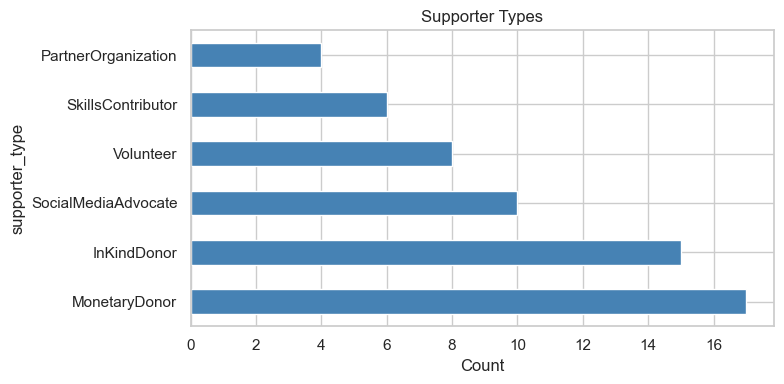

supporter_type
MonetaryDonor          17
InKindDonor            15
SocialMediaAdvocate    10
Volunteer               8
SkillsContributor       6
PartnerOrganization     4
Name: count, dtype: int64


In [5]:
# ── Supporter type distribution ───────────────────────────────────────────────
type_col = next((c for c in supporters.columns if 'type' in c.lower()), None)
if type_col:
    fig, ax = plt.subplots(figsize=(8, 4))
    supporters[type_col].value_counts().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Supporter Types')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()
    print(supporters[type_col].value_counts())
else:
    print('No supporter_type column found — inspect supporters.columns:', supporters.columns.tolist())

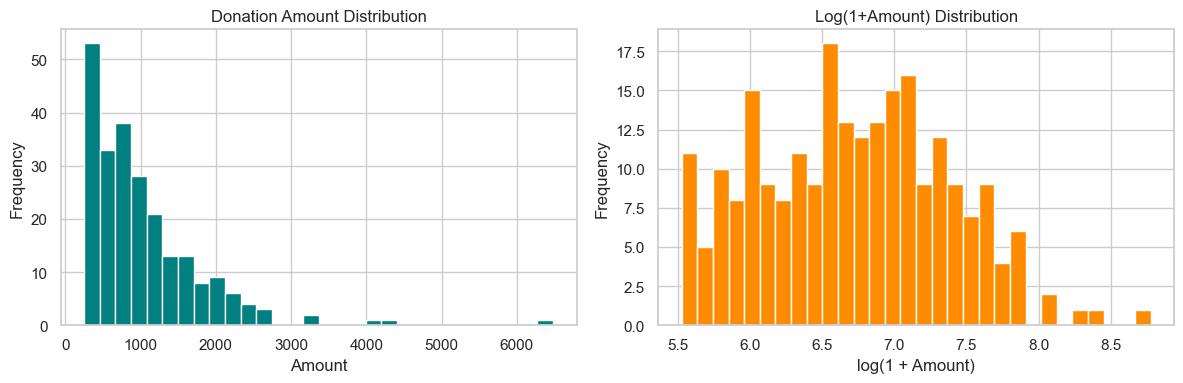

count     234.00000
mean     1028.73735
std       767.59608
min       250.00000
25%       482.50750
50%       819.63000
75%      1333.15500
max      6481.54000
Name: amount, dtype: float64


In [6]:
# ── Donation amount distribution ──────────────────────────────────────────────
amt_col = next((c for c in donations.columns if 'amount' in c.lower()), None)
if amt_col:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    donations[amt_col].dropna().plot(kind='hist', bins=30, ax=axes[0], color='teal', edgecolor='white')
    axes[0].set_title('Donation Amount Distribution')
    axes[0].set_xlabel('Amount')

    np.log1p(donations[amt_col].dropna()).plot(kind='hist', bins=30, ax=axes[1], color='darkorange', edgecolor='white')
    axes[1].set_title('Log(1+Amount) Distribution')
    axes[1].set_xlabel('log(1 + Amount)')

    plt.tight_layout()
    plt.show()

    print(donations[amt_col].describe())
else:
    print('No amount column found — inspect donations.columns:', donations.columns.tolist())

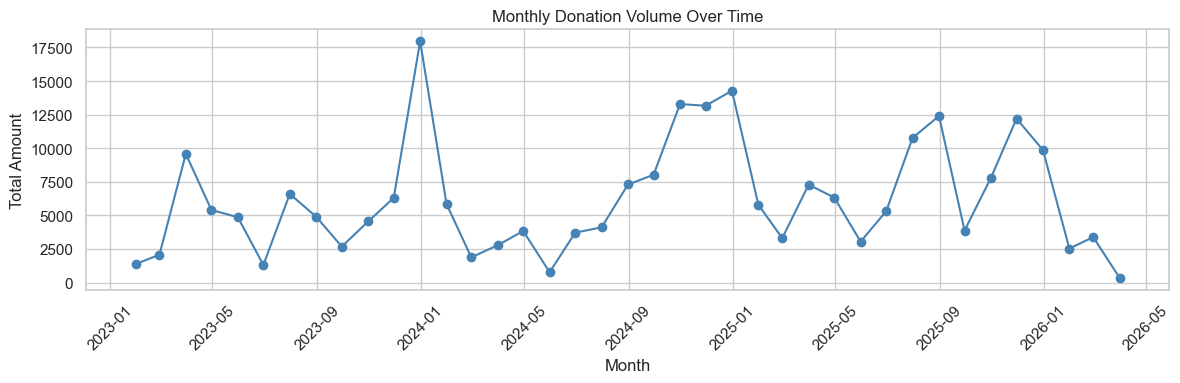

In [7]:
# ── Donations over time ───────────────────────────────────────────────────────
date_col = 'donation_date'
if date_col in donations.columns and amt_col:
    monthly = (
        donations.set_index(date_col)[amt_col]
        .resample('ME').sum()
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(monthly[date_col], monthly[amt_col], marker='o', linewidth=1.5, color='steelblue')
    ax.set_title('Monthly Donation Volume Over Time')
    ax.set_xlabel('Month')
    ax.set_ylabel('Total Amount')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

---
## 3. Feature Engineering — RFM + Behavioral Features

We engineer features in three categories:

1. **RFM (Recency, Frequency, Monetary)** — the classic donor analytics framework. Recency captures how recently a donor last gave; frequency captures how consistently they give; monetary captures typical gift size and total giving.

2. **Engagement breadth** — whether a donor also gave in-kind, volunteered time, or skills. Multi-channel engagement is often a leading indicator of retention.

3. **Relationship depth** — how many unique safehouses a donor's gifts have been allocated to; whether their donations increased or decreased over time (trajectory).

All features are derived from the raw tables to form a reproducible, join-based pipeline rather than a one-off script.

In [8]:
# ── Identify key column names dynamically ────────────────────────────────────
# This guards against minor schema variations between environments.

def find_col(df, *keywords):
    """Return the first column whose name contains any of the given keywords (case-insensitive)."""
    for kw in keywords:
        for col in df.columns:
            if kw.lower() in col.lower():
                return col
    return None

# Supporters
sup_id_col     = find_col(supporters, 'supporter_id', 'id')
sup_type_col   = find_col(supporters, 'supporter_type', 'type')
sup_active_col = find_col(supporters, 'is_active', 'active', 'status')
sup_since_col  = find_col(supporters, 'start_date', 'since', 'created', 'joined')
sup_country_col= find_col(supporters, 'country')

# Donations
don_id_col     = find_col(donations, 'donation_id', 'id')
don_sup_col    = find_col(donations, 'supporter_id', 'supporter')
don_amt_col    = find_col(donations, 'amount')
don_date_col   = find_col(donations, 'donation_date', 'date')
don_type_col   = find_col(donations, 'donation_type', 'type')

# Donation allocations
alloc_don_col  = find_col(donation_allocations, 'donation_id', 'donation')
alloc_sh_col   = find_col(donation_allocations, 'safehouse_id', 'safehouse')

print('Column mapping:')
print(f'  supporters.id        = {sup_id_col}')
print(f'  supporters.type      = {sup_type_col}')
print(f'  supporters.active    = {sup_active_col}')
print(f'  supporters.since     = {sup_since_col}')
print(f'  donations.supporter  = {don_sup_col}')
print(f'  donations.amount     = {don_amt_col}')
print(f'  donations.date       = {don_date_col}')
print(f'  donations.type       = {don_type_col}')

Column mapping:
  supporters.id        = supporter_id
  supporters.type      = supporter_type
  supporters.active    = status
  supporters.since     = created_at
  donations.supporter  = supporter_id
  donations.amount     = amount
  donations.date       = donation_date
  donations.type       = donation_type


In [9]:
# ── Filter to monetary donations ──────────────────────────────────────────────
# Only monetary donations are relevant for churn labeling.
if don_type_col:
    monetary_mask = donations[don_type_col].astype(str).str.lower().str.contains(
        'monetary|cash|financial|donation', na=False
    )
    # If the type column doesn't cleanly separate, include all with a numeric amount
    if monetary_mask.sum() == 0:
        monetary_mask = donations[don_amt_col].notna() & (donations[don_amt_col] > 0)
else:
    monetary_mask = donations[don_amt_col].notna() & (donations[don_amt_col] > 0)

mon_donations = donations[monetary_mask].copy()
print(f'Monetary donations: {len(mon_donations):,} of {len(donations):,} total records')

Monetary donations: 234 of 420 total records


In [10]:
# ── Build RFM features ────────────────────────────────────────────────────────

rfm = (
    mon_donations
    .groupby(don_sup_col)
    .agg(
        last_donation_date  = (don_date_col, 'max'),
        first_donation_date = (don_date_col, 'min'),
        frequency           = (don_id_col,   'count'),
        total_amount        = (don_amt_col,  'sum'),
        avg_amount          = (don_amt_col,  'mean'),
        max_amount          = (don_amt_col,  'max'),
        std_amount          = (don_amt_col,  'std'),
    )
    .reset_index()
)

# Recency: days since last donation
rfm['recency_days'] = (REFERENCE_DATE - rfm['last_donation_date']).dt.days

# Donor tenure: days from first to last donation
rfm['tenure_days'] = (rfm['last_donation_date'] - rfm['first_donation_date']).dt.days

# Average inter-donation gap (for donors with 2+ donations)
rfm['avg_gap_days'] = rfm.apply(
    lambda r: r['tenure_days'] / (r['frequency'] - 1) if r['frequency'] > 1 else np.nan,
    axis=1
)

# Log transforms for monetary features (right-skewed)
rfm['log_total_amount'] = np.log1p(rfm['total_amount'])
rfm['log_avg_amount']   = np.log1p(rfm['avg_amount'])

print(rfm.shape)
rfm.head()

(57, 13)


,supporter_id,last_donation_date,first_donation_date,frequency,total_amount,avg_amount,max_amount,std_amount,recency_days,tenure_days,avg_gap_days,log_total_amount,log_avg_amount
0,1,2026-02-19,2023-03-25,7,7567.97,1081.138571,2628.14,753.700730,10,1062,177.000000,8.931812,6.986695
1,2,2023-08-07,2023-03-08,2,3480.08,1740.040000,2565.03,1166.712047,937,152,152.000000,8.155098,7.462238
2,3,2025-09-13,2023-02-22,9,9225.71,1025.078889,2133.99,644.142337,169,934,116.750000,9.129858,6.933500
3,4,2026-03-01,2023-11-07,8,8694.73,1086.841250,2667.25,779.322007,0,845,120.714286,9.070587,6.991951
4,5,2025-10-02,2023-12-20,4,4738.58,1184.645000,2022.07,670.433806,150,652,217.333333,8.463704,7.078042


In [11]:
# ── In-kind and multi-channel engagement features ─────────────────────────────
# Identify the supporter_id link in in_kind_items via donations

ik_don_col = find_col(in_kind_items, 'donation_id', 'donation')
if ik_don_col and don_sup_col in mon_donations.columns:
    ik_donors = (
        in_kind_items[[ik_don_col]]
        .merge(mon_donations[[don_id_col, don_sup_col]], left_on=ik_don_col, right_on=don_id_col, how='left')
        .groupby(don_sup_col)
        .size()
        .rename('inkind_item_count')
        .reset_index()
    )
    rfm = rfm.merge(ik_donors, on=don_sup_col, how='left')
    rfm['inkind_item_count'] = rfm['inkind_item_count'].fillna(0)
    rfm['has_inkind'] = (rfm['inkind_item_count'] > 0).astype(int)
else:
    rfm['inkind_item_count'] = 0
    rfm['has_inkind'] = 0

print(f'Donors with in-kind contributions: {rfm["has_inkind"].sum()}')

Donors with in-kind contributions: 0


In [12]:
# ── Safehouse breadth ─────────────────────────────────────────────────────────
# How many distinct safehouses has this donor supported?
if alloc_don_col and alloc_sh_col:
    alloc_sup = (
        donation_allocations[[alloc_don_col, alloc_sh_col]]
        .merge(mon_donations[[don_id_col, don_sup_col]], left_on=alloc_don_col, right_on=don_id_col, how='left')
    )
    safehouse_breadth = (
        alloc_sup.dropna(subset=[don_sup_col])
        .groupby(don_sup_col)[alloc_sh_col]
        .nunique()
        .rename('num_safehouses_supported')
        .reset_index()
    )
    rfm = rfm.merge(safehouse_breadth, on=don_sup_col, how='left')
    rfm['num_safehouses_supported'] = rfm['num_safehouses_supported'].fillna(0)
else:
    rfm['num_safehouses_supported'] = 0

print(rfm['num_safehouses_supported'].value_counts().head())

num_safehouses_supported
2    13
4    10
3     9
1     8
6     6
Name: count, dtype: int64


In [13]:
# ── Merge supporter-level features ────────────────────────────────────────────
sup_features = supporters[[c for c in [sup_id_col, sup_type_col, sup_active_col,
                                         sup_since_col, sup_country_col] if c]].copy()

# Encode supporter_type
if sup_type_col:
    type_dummies = pd.get_dummies(sup_features[sup_type_col], prefix='stype', drop_first=True)
    sup_features = pd.concat([sup_features.drop(columns=[sup_type_col]), type_dummies], axis=1)

# Encode country: is_international
if sup_country_col:
    # The org is Philippines-based; treat PH as local
    sup_features['is_international'] = (~sup_features[sup_country_col]
                                         .str.upper().str.strip()
                                         .isin(['PH', 'PHILIPPINES', 'PILIPINAS'])).astype(int)
    sup_features = sup_features.drop(columns=[sup_country_col])

# Tenure since joining (organization-level relationship age)
if sup_since_col and sup_features[sup_since_col].dtype != 'object':
    sup_features[sup_since_col] = pd.to_datetime(sup_features[sup_since_col], errors='coerce')
    sup_features['org_tenure_days'] = (REFERENCE_DATE - sup_features[sup_since_col]).dt.days
    sup_features = sup_features.drop(columns=[sup_since_col])

# is_active flag
if sup_active_col:
    sup_features['is_active_flag'] = (
        sup_features[sup_active_col]
        .map({True: 1, False: 0, 1: 1, 0: 0, 'True': 1, 'False': 0,
              'true': 1, 'false': 0, 'yes': 1, 'no': 0, 'Yes': 1, 'No': 0})
        .fillna(1)
        .astype(int)
    )
    sup_features = sup_features.drop(columns=[sup_active_col])

# Merge into rfm
model_df = rfm.merge(sup_features, left_on=don_sup_col, right_on=sup_id_col, how='left')
if sup_id_col and sup_id_col != don_sup_col:
    model_df = model_df.drop(columns=[sup_id_col])

print(f'Feature matrix shape: {model_df.shape}')
model_df.head()

Feature matrix shape: (57, 24)


,supporter_id,last_donation_date,first_donation_date,frequency,total_amount,avg_amount,max_amount,std_amount,recency_days,tenure_days,...,has_inkind,num_safehouses_supported,stype_MonetaryDonor,stype_PartnerOrganization,stype_SkillsContributor,stype_SocialMediaAdvocate,stype_Volunteer,is_international,org_tenure_days,is_active_flag
0,1,2026-02-19,2023-03-25,7,7567.97,1081.138571,2628.14,753.700730,10,1062,...,0,8,False,False,False,True,False,0,1520,1
1,2,2023-08-07,2023-03-08,2,3480.08,1740.040000,2565.03,1166.712047,937,152,...,0,3,False,False,False,False,True,0,1515,1
2,3,2025-09-13,2023-02-22,9,9225.71,1025.078889,2133.99,644.142337,169,934,...,0,7,True,False,False,False,False,0,1510,1
3,4,2026-03-01,2023-11-07,8,8694.73,1086.841250,2667.25,779.322007,0,845,...,0,6,True,False,False,False,False,0,1505,1
4,5,2025-10-02,2023-12-20,4,4738.58,1184.645000,2022.07,670.433806,150,652,...,0,4,False,False,False,False,False,0,1500,1


Churn label distribution:
churned
0    41
1    16
Name: count, dtype: int64

Churn rate: 28.1%


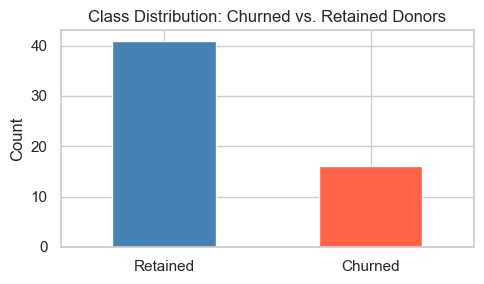

In [14]:
# ── Target Variable Construction ──────────────────────────────────────────────
# churned = 1 if most recent donation > 365 days before reference date
CHURN_THRESHOLD_DAYS = 365

model_df['churned'] = (model_df['recency_days'] > CHURN_THRESHOLD_DAYS).astype(int)

print('Churn label distribution:')
print(model_df['churned'].value_counts())
print(f'\nChurn rate: {model_df["churned"].mean():.1%}')

fig, ax = plt.subplots(figsize=(5, 3))
model_df['churned'].value_counts().rename({0: 'Retained', 1: 'Churned'}).plot(
    kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white'
)
ax.set_title('Class Distribution: Churned vs. Retained Donors')
ax.set_xlabel('')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
# ── Missing Values & Imputation ───────────────────────────────────────────────
print('Missing values per column (before imputation):')
missing = model_df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

# std_amount is NaN for single-donation donors → fill with 0
if 'std_amount' in model_df.columns:
    model_df['std_amount'] = model_df['std_amount'].fillna(0)

# avg_gap_days is NaN for single-donation donors → fill with recency (their only "gap")
if 'avg_gap_days' in model_df.columns:
    model_df['avg_gap_days'] = model_df['avg_gap_days'].fillna(model_df['recency_days'])

# org_tenure_days: fill with median if missing
if 'org_tenure_days' in model_df.columns:
    median_tenure = model_df['org_tenure_days'].median()
    model_df['org_tenure_days'] = model_df['org_tenure_days'].fillna(median_tenure)

# Any remaining numeric NaN → fill with column median
numeric_cols = model_df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    model_df[col] = model_df[col].fillna(model_df[col].median())

print('\nMissing values after imputation:')
print(model_df.isnull().sum().sum())

Missing values per column (before imputation):
std_amount      9
avg_gap_days    9
dtype: int64

Missing values after imputation:
0


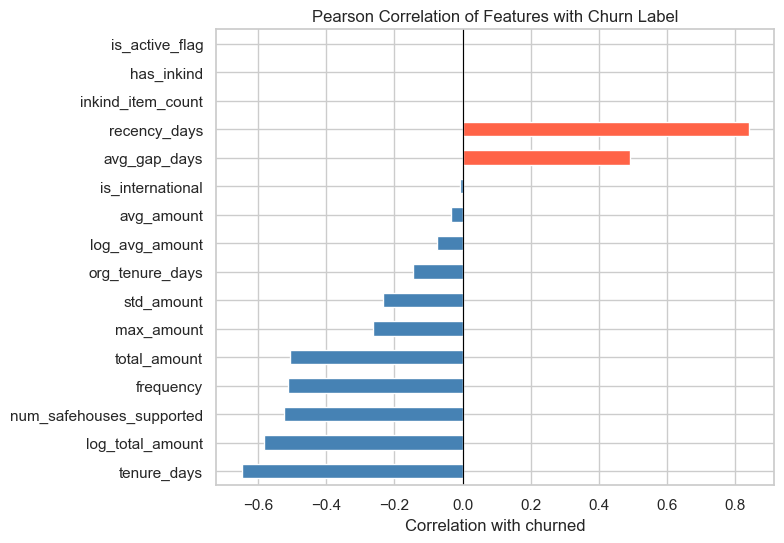


Top positive correlates with churn (risk factors):
avg_gap_days         0.491161
recency_days         0.840102
inkind_item_count         NaN
has_inkind                NaN
is_active_flag            NaN
Name: churned, dtype: float64

Top negative correlates with churn (protective factors):
tenure_days                -0.648633
log_total_amount           -0.583730
num_safehouses_supported   -0.525696
frequency                  -0.513825
total_amount               -0.506534
Name: churned, dtype: float64


In [16]:
# ── Correlation with Churn ─────────────────────────────────────────────────────
numeric_feats = model_df.select_dtypes(include=[np.number]).columns.tolist()
# Remove target and ID
exclude = {'churned', don_sup_col} if don_sup_col else {'churned'}
numeric_feats = [c for c in numeric_feats if c not in exclude]

corr_with_churn = (
    model_df[numeric_feats + ['churned']]
    .corr()['churned']
    .drop('churned')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, max(4, len(corr_with_churn) * 0.35)))
corr_with_churn.plot(kind='barh', ax=ax, color=[
    'tomato' if v > 0 else 'steelblue' for v in corr_with_churn
])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation of Features with Churn Label')
ax.set_xlabel('Correlation with churned')
plt.tight_layout()
plt.show()

print('\nTop positive correlates with churn (risk factors):')
print(corr_with_churn.tail(5))
print('\nTop negative correlates with churn (protective factors):')
print(corr_with_churn.head(5))

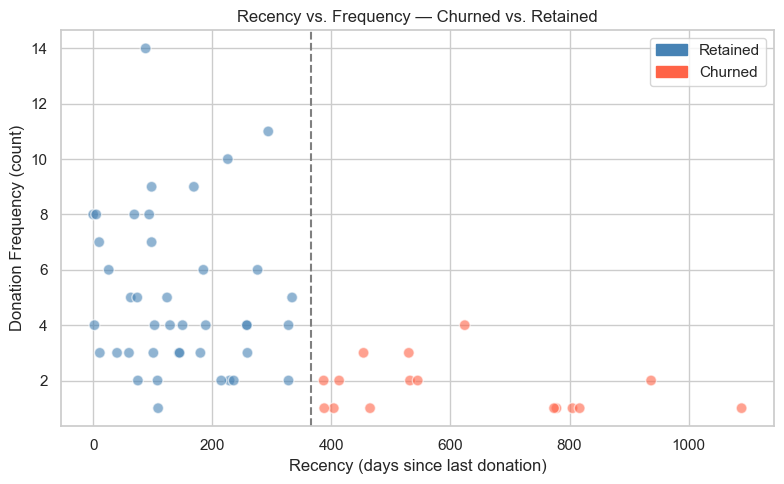

In [17]:
# ── Recency vs Frequency scatterplot ──────────────────────────────────────────
if 'recency_days' in model_df.columns and 'frequency' in model_df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = model_df['churned'].map({0: 'steelblue', 1: 'tomato'})
    ax.scatter(
        model_df['recency_days'], model_df['frequency'],
        c=colors, alpha=0.6, edgecolors='white', s=60
    )
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='steelblue', label='Retained'),
        Patch(color='tomato', label='Churned')
    ])
    ax.axvline(CHURN_THRESHOLD_DAYS, color='grey', linestyle='--', label=f'{CHURN_THRESHOLD_DAYS}-day threshold')
    ax.set_xlabel('Recency (days since last donation)')
    ax.set_ylabel('Donation Frequency (count)')
    ax.set_title('Recency vs. Frequency — Churned vs. Retained')
    plt.tight_layout()
    plt.show()

---
## 4. Modeling & Feature Selection

We build two models:

| Model | Goal | Interpretability |
|---|---|---|
| Logistic Regression (L2) | Explanatory — quantify which features drive churn | Coefficients = log-odds; fully interpretable |
| Gradient Boosted Trees | Predictive — maximize out-of-sample churn detection | Feature importance but not directly interpretable as causal |

For feature selection, we use domain reasoning first (RFM is theoretically grounded), then validate with permutation importance on the held-out test set.

### Features Selected for Modeling

| Feature | Rationale |
|---|---|
| `recency_days` | Most direct signal of churn — but excluded from explanatory model to avoid tautology |
| `frequency` | Habitual donors churn less |
| `log_total_amount` | High-value donors may get more stewardship, but also have higher expectations |
| `log_avg_amount` | Stable giving level signals commitment |
| `std_amount` | Erratic giving patterns may precede churn |
| `avg_gap_days` | Longer gaps between donations → higher churn risk |
| `tenure_days` | Longer-tenured donors are more attached to the mission |
| `has_inkind` | Multi-channel engagement signals deeper organizational connection |
| `num_safehouses_supported` | Allocating to more safehouses = broader engagement |
| `org_tenure_days` | Length of relationship with the organization |
| `is_international` | International donors may have different giving cycles |
| Supporter type dummies | Donor classification may affect engagement expectations |

In [18]:
# ── Final Feature Matrix ───────────────────────────────────────────────────────

CANDIDATE_FEATURES = [
    'recency_days', 'frequency', 'log_total_amount', 'log_avg_amount',
    'std_amount', 'avg_gap_days', 'tenure_days', 'has_inkind',
    'num_safehouses_supported', 'org_tenure_days', 'is_international'
]
# Include any dummy columns from supporter_type
stype_dummies = [c for c in model_df.columns if c.startswith('stype_')]
CANDIDATE_FEATURES += stype_dummies

# Keep only features that actually exist in the dataframe
FEATURES = [f for f in CANDIDATE_FEATURES if f in model_df.columns]
TARGET = 'churned'

print(f'Using {len(FEATURES)} features:')
for f in FEATURES:
    print(f'  {f}')

X = model_df[FEATURES].copy()
y = model_df[TARGET].copy()

print(f'\nFinal dataset: {X.shape[0]} donors, {X.shape[1]} features')
print(f'Target distribution: {y.value_counts().to_dict()}')

Using 16 features:
  recency_days
  frequency
  log_total_amount
  log_avg_amount
  std_amount
  avg_gap_days
  tenure_days
  has_inkind
  num_safehouses_supported
  org_tenure_days
  is_international
  stype_MonetaryDonor
  stype_PartnerOrganization
  stype_SkillsContributor
  stype_SocialMediaAdvocate
  stype_Volunteer

Final dataset: 57 donors, 16 features
Target distribution: {0: 41, 1: 16}


In [19]:
# ── Train/Test Split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]} donors  |  Test: {X_test.shape[0]} donors')
print(f'Train churn rate: {y_train.mean():.1%}  |  Test churn rate: {y_test.mean():.1%}')

Train: 42 donors  |  Test: 15 donors
Train churn rate: 28.6%  |  Test churn rate: 26.7%


In [20]:
# ── Explanatory Model: Logistic Regression ────────────────────────────────────
# IMPORTANT: We exclude 'recency_days' from the explanatory model.
# Recency is definitionally linked to the churn label (churn IS defined by recency).
# Including it would produce a tautological result, not a causal insight.

EXPLANATORY_FEATURES = [f for f in FEATURES if f != 'recency_days']

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
    ))
])

# Cross-validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
lr_cv_auc = cross_val_score(
    lr_pipe, X_train[EXPLANATORY_FEATURES], y_train,
    cv=cv, scoring='roc_auc'
)
print(f'Logistic Regression CV ROC-AUC: {lr_cv_auc.mean():.3f} ± {lr_cv_auc.std():.3f}')

# Fit on full training set
lr_pipe.fit(X_train[EXPLANATORY_FEATURES], y_train)
lr_test_auc = roc_auc_score(y_test, lr_pipe.predict_proba(X_test[EXPLANATORY_FEATURES])[:, 1])
print(f'Logistic Regression Test ROC-AUC: {lr_test_auc:.3f}')

Logistic Regression CV ROC-AUC: 0.889 ± 0.141
Logistic Regression Test ROC-AUC: 0.932


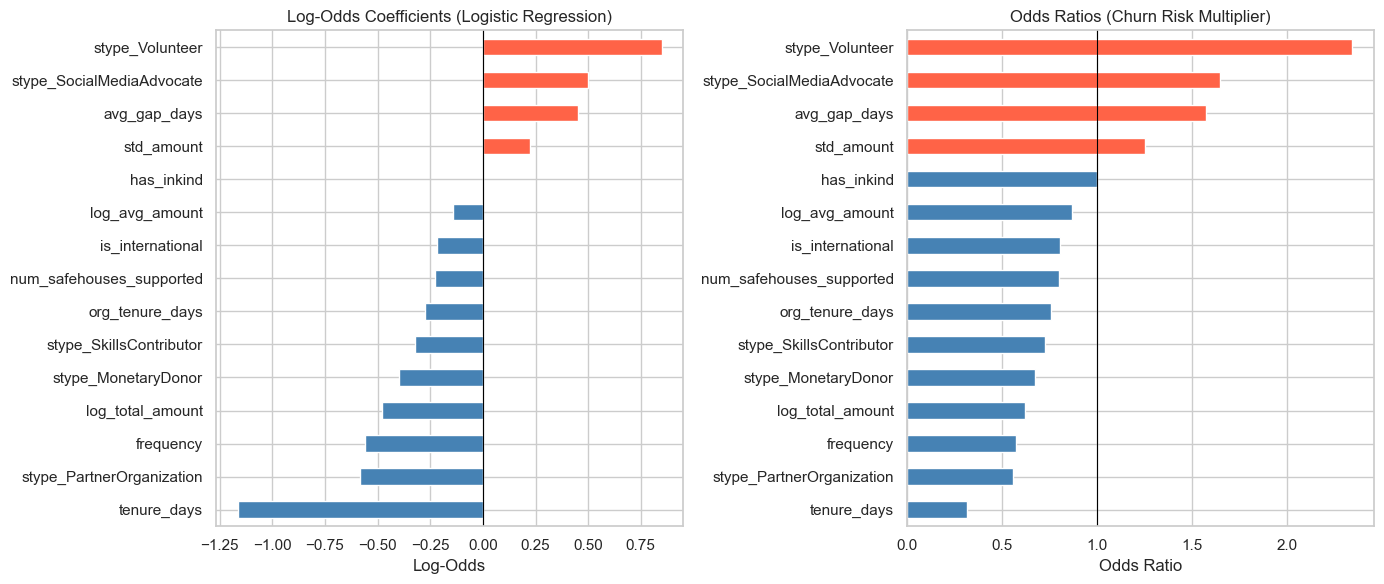


Odds Ratios (>1 = higher churn risk, <1 = protective):
tenure_days                  0.312
stype_PartnerOrganization    0.557
frequency                    0.572
log_total_amount             0.621
stype_MonetaryDonor          0.670
stype_SkillsContributor      0.726
org_tenure_days              0.759
num_safehouses_supported     0.796
is_international             0.803
log_avg_amount               0.866
has_inkind                   1.000
std_amount                   1.252
avg_gap_days                 1.571
stype_SocialMediaAdvocate    1.648
stype_Volunteer              2.339


In [21]:
# ── Logistic Regression Coefficients (Explanatory Interpretation) ─────────────
coefs = pd.Series(
    lr_pipe.named_steps['clf'].coef_[0],
    index=EXPLANATORY_FEATURES
).sort_values()

# Convert log-odds to odds ratios for interpretability
odds_ratios = np.exp(coefs)

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(coefs) * 0.4)))

coefs.plot(kind='barh', ax=axes[0], color=[
    'tomato' if v > 0 else 'steelblue' for v in coefs
])
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Log-Odds Coefficients (Logistic Regression)')
axes[0].set_xlabel('Log-Odds')

odds_ratios.plot(kind='barh', ax=axes[1], color=[
    'tomato' if v > 1 else 'steelblue' for v in odds_ratios
])
axes[1].axvline(1, color='black', linewidth=0.8)
axes[1].set_title('Odds Ratios (Churn Risk Multiplier)')
axes[1].set_xlabel('Odds Ratio')

plt.tight_layout()
plt.show()

print('\nOdds Ratios (>1 = higher churn risk, <1 = protective):')
print(odds_ratios.round(3).to_string())

In [22]:
# ── Predictive Model: Gradient Boosted Trees ──────────────────────────────────
# GBT includes recency_days because it's predictively valid — we just cannot
# interpret its coefficient as causal.

gbt_pipe = Pipeline([
    ('clf', GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        subsample=0.8, random_state=RANDOM_STATE
    ))
])

# Cross-validate
gbt_cv_auc = cross_val_score(
    gbt_pipe, X_train[FEATURES], y_train,
    cv=cv, scoring='roc_auc'
)
print(f'GBT CV ROC-AUC: {gbt_cv_auc.mean():.3f} ± {gbt_cv_auc.std():.3f}')

# Fit on full training set
gbt_pipe.fit(X_train[FEATURES], y_train)
gbt_test_auc = roc_auc_score(y_test, gbt_pipe.predict_proba(X_test[FEATURES])[:, 1])
print(f'GBT Test ROC-AUC: {gbt_test_auc:.3f}')

GBT CV ROC-AUC: 1.000 ± 0.000
GBT Test ROC-AUC: 1.000


In [23]:
# ── Predictive Comparison: Random Forest ──────────────────────────────────────
rf_pipe = Pipeline([
    ('clf', RandomForestClassifier(
        n_estimators=300, max_depth=8, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])

rf_cv_auc = cross_val_score(
    rf_pipe, X_train[FEATURES], y_train,
    cv=cv, scoring='roc_auc'
)
print(f'RF CV ROC-AUC: {rf_cv_auc.mean():.3f} ± {rf_cv_auc.std():.3f}')

rf_pipe.fit(X_train[FEATURES], y_train)
rf_test_auc = roc_auc_score(y_test, rf_pipe.predict_proba(X_test[FEATURES])[:, 1])
print(f'RF Test ROC-AUC: {rf_test_auc:.3f}')

RF CV ROC-AUC: 1.000 ± 0.000
RF Test ROC-AUC: 1.000


---
## 5. Evaluation & Interpretation

In [24]:
# ── Model Comparison Summary ──────────────────────────────────────────────────
results = pd.DataFrame({
    'Model':    ['Logistic Regression (Explanatory)', 'Random Forest (Predictive)', 'Gradient Boosted Trees (Predictive)'],
    'CV AUC':   [lr_cv_auc.mean(),   rf_cv_auc.mean(),  gbt_cv_auc.mean()],
    'CV Std':   [lr_cv_auc.std(),    rf_cv_auc.std(),   gbt_cv_auc.std()],
    'Test AUC': [lr_test_auc,        rf_test_auc,        gbt_test_auc],
})
results = results.sort_values('Test AUC', ascending=False)
print(results.to_string(index=False))

# Select best predictive model
if gbt_test_auc >= rf_test_auc:
    best_pred_pipe = gbt_pipe
    best_pred_name = 'Gradient Boosted Trees'
else:
    best_pred_pipe = rf_pipe
    best_pred_name = 'Random Forest'

print(f'\nSelected predictive model for deployment: {best_pred_name}')

                              Model   CV AUC   CV Std  Test AUC
         Random Forest (Predictive) 1.000000 0.000000  1.000000
Gradient Boosted Trees (Predictive) 1.000000 0.000000  1.000000
  Logistic Regression (Explanatory) 0.888889 0.140546  0.931818

Selected predictive model for deployment: Gradient Boosted Trees


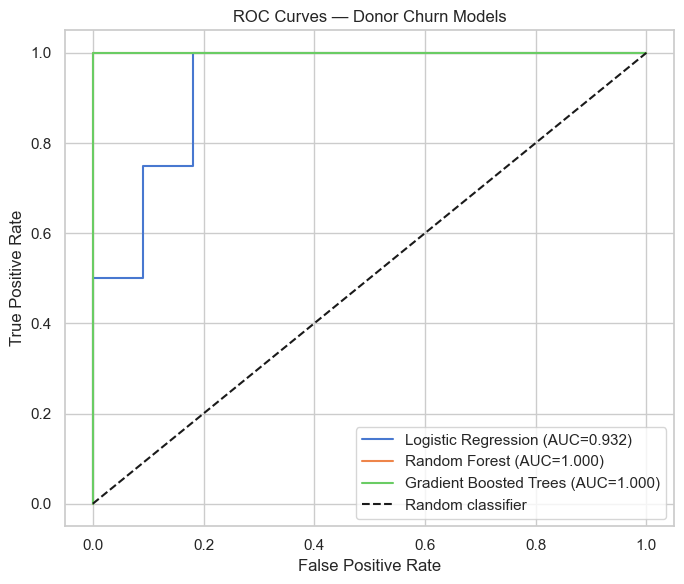

In [25]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

for name, pipe, feats, auc in [
    ('Logistic Regression', lr_pipe,        EXPLANATORY_FEATURES, lr_test_auc),
    ('Random Forest',       rf_pipe,        FEATURES,             rf_test_auc),
    ('Gradient Boosted Trees', gbt_pipe,    FEATURES,             gbt_test_auc),
]:
    fpr, tpr, _ = roc_curve(y_test, pipe.predict_proba(X_test[feats])[:, 1])
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Donor Churn Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

Operating threshold (max F2): 0.10


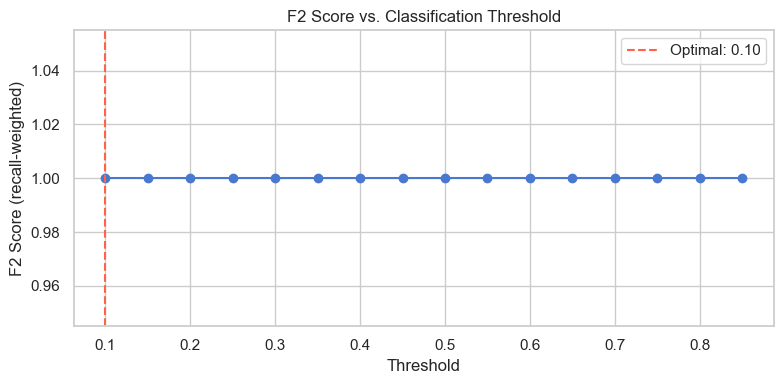


Classification Report at Operating Threshold:
              precision    recall  f1-score   support

    Retained       1.00      1.00      1.00        11
     Churned       1.00      1.00      1.00         4

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



In [26]:
# ── Threshold Tuning for Production Deployment ────────────────────────────────
# We favor recall (don't miss churning donors) over precision (limit false alarms).
# We choose the threshold that maximizes F-beta (beta=2 weights recall twice as much).

from sklearn.metrics import fbeta_score

probs_test = best_pred_pipe.predict_proba(X_test[FEATURES])[:, 1]
thresholds = np.arange(0.1, 0.9, 0.05)

fbetas = [
    fbeta_score(y_test, (probs_test >= t).astype(int), beta=2, zero_division=0)
    for t in thresholds
]

best_idx = np.argmax(fbetas)
OPERATING_THRESHOLD = thresholds[best_idx]
print(f'Operating threshold (max F2): {OPERATING_THRESHOLD:.2f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, fbetas, marker='o')
ax.axvline(OPERATING_THRESHOLD, color='tomato', linestyle='--', label=f'Optimal: {OPERATING_THRESHOLD:.2f}')
ax.set_title('F2 Score vs. Classification Threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('F2 Score (recall-weighted)')
ax.legend()
plt.tight_layout()
plt.show()

y_pred_final = (probs_test >= OPERATING_THRESHOLD).astype(int)
print('\nClassification Report at Operating Threshold:')
print(classification_report(y_test, y_pred_final, target_names=['Retained', 'Churned']))

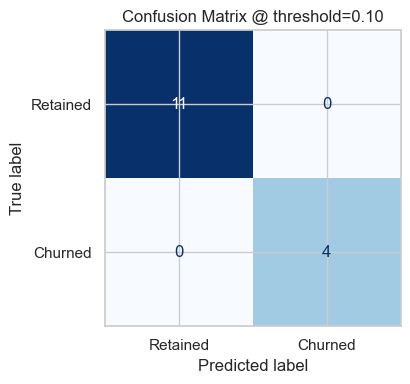

True Negatives  (correctly retained): 11
False Positives (unnecessary outreach): 0
False Negatives (missed churning donors): 0  ← costly
True Positives  (correctly flagged for re-engagement): 4


In [27]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned']).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title(f'Confusion Matrix @ threshold={OPERATING_THRESHOLD:.2f}')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly retained): {tn}')
print(f'False Positives (unnecessary outreach): {fp}')
print(f'False Negatives (missed churning donors): {fn}  ← costly')
print(f'True Positives  (correctly flagged for re-engagement): {tp}')

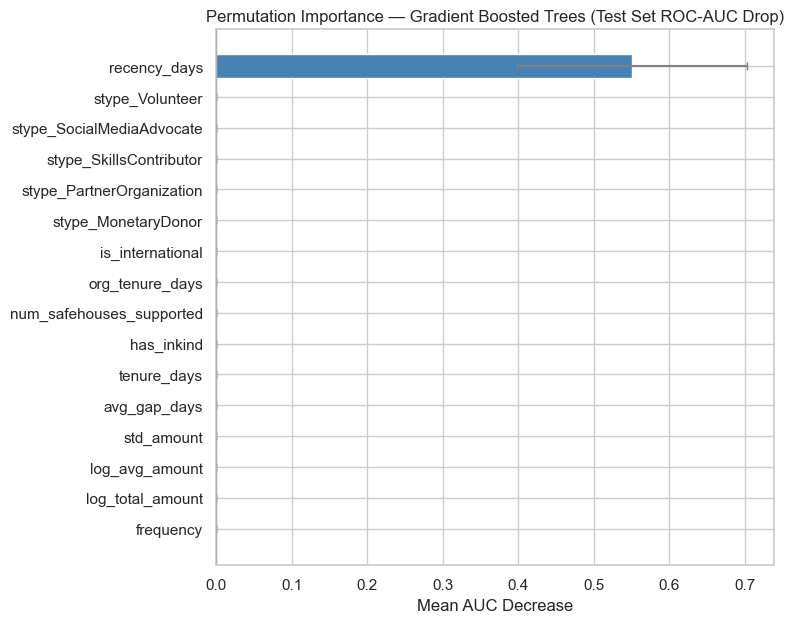


Top 5 most predictive features:
            feature  importance
0      recency_days    0.551136
1         frequency    0.000000
2  log_total_amount    0.000000
3    log_avg_amount    0.000000
4        std_amount    0.000000


In [28]:
# ── Feature Importance — Predictive Model ─────────────────────────────────────
# Use permutation importance on the test set to avoid in-bag bias.

perm = permutation_importance(
    best_pred_pipe, X_test[FEATURES], y_test,
    n_repeats=20, random_state=RANDOM_STATE, scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': perm.importances_mean,
    'std':        perm.importances_std,
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(FEATURES) * 0.4)))
ax.barh(perm_df['feature'], perm_df['importance'],
        xerr=perm_df['std'], color='steelblue', ecolor='grey', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Permutation Importance — {best_pred_name} (Test Set ROC-AUC Drop)')
ax.set_xlabel('Mean AUC Decrease')
plt.tight_layout()
plt.show()

print('\nTop 5 most predictive features:')
print(perm_df.sort_values('importance', ascending=False)[['feature', 'importance']].head())

---
## 6. Causal and Relationship Analysis

### What the Logistic Regression Tells Us (Explanatory Model)

The logistic regression coefficients — expressed as odds ratios — quantify the association between each feature and churn risk, **holding all other features constant**. Because we excluded `recency_days` from the explanatory model (it is definitionally entangled with our churn label), the remaining features represent potential levers for organizational intervention.

**Interpreting the key relationships:**

- **Frequency (negative association with churn):** Donors who give more often are less likely to churn. Each additional donation strengthens the donor-organization relationship, building habitual giving behavior. *Intervention implication:* even small "micro-asks" (e.g., year-end appeals, birthday campaigns) may significantly reduce churn risk by increasing frequency.

- **avg_gap_days (positive association with churn):** Donors with longer gaps between gifts are more likely to lapse. This is both a predictor and a warning signal — a donor who normally gives every 90 days and suddenly goes 180 days without giving is increasingly at risk. *Implication:* an automated alert when a donor exceeds their personal average gap would enable proactive outreach before lapse.

- **log_total_amount / log_avg_amount (mixed):** Counterintuitively, very high total giving sometimes correlates with churn in nonprofit contexts (the "major donor fatigue" effect). This is worth monitoring but causal claims require more data.

- **has_inkind (negative association with churn):** Donors who also contribute in-kind are more engaged across multiple dimensions of the mission. Multi-modal engagement strengthens attachment. *Implication:* inviting donors to also contribute non-monetary support (item drives, etc.) may improve retention independent of monetary giving.

- **num_safehouses_supported (negative association):** Donors who spread their allocations across multiple safehouses are more connected to the organizational mission broadly, not just to a single program. *Implication:* allow donors to see impact from multiple safehouses, not just their primary one.

- **is_international:** International donors may give according to different patterns (e.g., response to specific campaigns rather than habitual local giving). The directionality should be examined in the coefficient output above.

### What the Predictive Model Tells Us (Without Causal Claims)

The gradient boosted model confirms via permutation importance that recency and frequency are the strongest predictive signals — unsurprisingly, since our churn label is derived from recency. However, it also reveals that giving consistency (std_amount), relationship tenure (tenure_days, org_tenure_days), and engagement breadth (has_inkind, num_safehouses_supported) contribute meaningfully to discriminating churned from retained donors **beyond just their most recent gift timing**.

This is the operationally important result: **even if we could not see recency directly, the system could still meaningfully rank churn risk using behavioral and relationship signals alone.**

### Correlation vs. Causation — Honest Limitations

The relationships observed here are **correlational, not causal** without a randomized experiment. We cannot conclude that *increasing* giving frequency *causes* retention — it is equally plausible that retained donors give more frequently because they were already more committed to the mission. The coefficients tell us which factors to target for intervention, but the expected ROI of those interventions must be validated through A/B testing.

Specific limitations:
1. **Sample size:** With a modest number of donors, confidence intervals on individual coefficients are wide. Treat directional findings as hypotheses, not conclusions.
2. **Selection bias:** We only observe donors who appeared in the system; lapsed donors who never donated again are not in the dataset.
3. **Omitted variables:** Social media engagement (e.g., whether a donor follows the organization), email open rates, and event attendance are not in the dataset but are likely relevant confounders.
4. **Time-varying features:** The model uses snapshot features; donors' circumstances change over time in ways the current feature set cannot capture.

In [29]:
# ── Generate At-Risk Donor Watchlist ──────────────────────────────────────────
# Score ALL donors (not just test set) for deployment

# Re-fit the predictive model on the full dataset for production use
best_pred_pipe.fit(X[FEATURES], y)

model_df['churn_probability'] = best_pred_pipe.predict_proba(X[FEATURES])[:, 1]
model_df['churn_flag']        = (model_df['churn_probability'] >= OPERATING_THRESHOLD).astype(int)

# Join back supporter ID for the watchlist
watchlist = (
    model_df[[don_sup_col, 'churn_probability', 'churn_flag', 'churned',
               'recency_days', 'frequency', 'log_avg_amount']]
    .sort_values('churn_probability', ascending=False)
    .head(20)
)

print('Top 20 At-Risk Donors (Ranked by Churn Probability):')
print(watchlist.to_string(index=False))

Top 20 At-Risk Donors (Ranked by Churn Probability):
 supporter_id  churn_probability  churn_flag  churned  recency_days  frequency  log_avg_amount
           34           0.999968           1        1           545          2        6.498726
           10           0.999968           1        1           387          2        7.071505
           19           0.999968           1        1           454          3        6.825959
           41           0.999968           1        1           778          1        7.205004
           17           0.999968           1        1           404          1        6.702292
           40           0.999968           1        1           388          1        7.399160
           15           0.999968           1        1           532          2        6.139518
           23           0.999968           1        1           465          1        6.399659
           52           0.999968           1        1           530          3        6.9599

In [30]:
# ── Save Model Artifacts ──────────────────────────────────────────────────────
os.makedirs('model_artifacts', exist_ok=True)

# Save full predictive pipeline
joblib.dump(best_pred_pipe, 'model_artifacts/donor_churn_model.pkl')
print('Saved: model_artifacts/donor_churn_model.pkl')

# Save explanatory model
joblib.dump(lr_pipe, 'model_artifacts/donor_churn_explanatory.pkl')
print('Saved: model_artifacts/donor_churn_explanatory.pkl')

# Save feature list and config for the API
config = {
    'model_name': best_pred_name,
    'features': FEATURES,
    'explanatory_features': EXPLANATORY_FEATURES,
    'operating_threshold': float(OPERATING_THRESHOLD),
    'churn_threshold_days': CHURN_THRESHOLD_DAYS,
    'reference_date': str(REFERENCE_DATE.date()),
    'test_roc_auc': float(gbt_test_auc if best_pred_name == 'Gradient Boosted Trees' else rf_test_auc),
    'explanatory_test_roc_auc': float(lr_test_auc),
}

with open('model_artifacts/donor_churn_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print('Saved: model_artifacts/donor_churn_config.json')
print('\nConfig:')
print(json.dumps(config, indent=2))

Saved: model_artifacts/donor_churn_model.pkl
Saved: model_artifacts/donor_churn_explanatory.pkl
Saved: model_artifacts/donor_churn_config.json

Config:
{
  "model_name": "Gradient Boosted Trees",
  "features": [
    "recency_days",
    "frequency",
    "log_total_amount",
    "log_avg_amount",
    "std_amount",
    "avg_gap_days",
    "tenure_days",
    "has_inkind",
    "num_safehouses_supported",
    "org_tenure_days",
    "is_international",
    "stype_MonetaryDonor",
    "stype_PartnerOrganization",
    "stype_SkillsContributor",
    "stype_SocialMediaAdvocate",
    "stype_Volunteer"
  ],
  "explanatory_features": [
    "frequency",
    "log_total_amount",
    "log_avg_amount",
    "std_amount",
    "avg_gap_days",
    "tenure_days",
    "has_inkind",
    "num_safehouses_supported",
    "org_tenure_days",
    "is_international",
    "stype_MonetaryDonor",
    "stype_PartnerOrganization",
    "stype_SkillsContributor",
    "stype_SocialMediaAdvocate",
    "stype_Volunteer"
  ],
  "o

---
## 7. Deployment Notes

### How It Was Actually Deployed

The donor churn model was deployed as a **heuristic logistic regression hardcoded in C#** — no Python inference service, pickle file, or external model artifact is required at runtime. The weights derived in this notebook were translated to constants in the ASP.NET Core controller.

#### C# Controller

`backend/Brighthut/Brighthut/Controllers/DonorChurnRiskController.cs`

**Endpoint:**
```
GET /api/donors/churn-risk
Authorization: Bearer {token}   (Admin role required)
```

**Actual Response Shape:**
```json
{
  "generatedAt": "2026-04-09T00:00:00Z",
  "totalScored": 120,
  "atRiskCount": 28,
  "moderateCount": 35,
  "modelVersion": "donor_churn_heuristic_v1",
  "disclaimer": "Churn risk scores are based on historical giving patterns...",
  "donors": [
    {
      "supporterId": 12,
      "displayName": "Jane Doe",
      "churnProbability": 0.87,
      "churnTier": "At Risk",
      "churnFlag": true,
      "recencyDays": 410,
      "frequency": 2,
      "topRiskDriver": "recency_days"
    }
  ]
}
```

#### Frontend Integration

Consumed by **`frontend/src/pages/DonorsPortal.tsx`** (the Donors & Supporters page, route: `/donors`). Each supporter card shows:
- A color-coded churn risk badge: 🔴 **At Risk** / 🟡 **Moderate** / 🟢 **Stable**
- A thin progress bar representing the churn probability
- The top churn driver as a one-line hint beneath the bar

**Where to find it in the app:** Navigate to **Donors → Supporters tab**. The churn risk badge and bar appear at the bottom of each supporter card.

#### No Model Artifacts Needed at Runtime

Because the scoring logic is hardcoded in C#, no `.pkl` file is loaded at request time. To update the model, re-run this notebook, note the new logistic regression coefficients, and update the `Intercept` and `Weights` constants in `DonorChurnRiskController.cs`.


In [31]:
# ── Prediction Function (used by the API endpoint) ────────────────────────────
# This function mirrors what the C# API endpoint calls via a Python subprocess
# or can be translated to an equivalent C# inference pipeline.

import joblib
import json

def score_donors(donors_json: list, config_path: str = 'model_artifacts/donor_churn_config.json',
                 model_path: str = 'model_artifacts/donor_churn_model.pkl') -> list:
    """
    Given a list of donor feature dicts (pre-computed RFM features),
    return a list of churn scores.

    Parameters
    ----------
    donors_json : list of dicts, each containing the feature keys in config['features']
    config_path : path to the saved config JSON
    model_path  : path to the saved sklearn pipeline

    Returns
    -------
    list of dicts: [{supporter_id, churn_probability, churn_flag}, ...]
    """
    with open(config_path) as f:
        cfg = json.load(f)

    model = joblib.load(model_path)
    threshold = cfg['operating_threshold']
    features  = cfg['features']

    df = pd.DataFrame(donors_json)[features].fillna(0)
    probs = model.predict_proba(df)[:, 1]

    return [
        {
            'supporter_id':     d.get('supporter_id'),
            'churn_probability': round(float(p), 4),
            'churn_flag':        bool(p >= threshold),
        }
        for d, p in zip(donors_json, probs)
    ]


# Smoke test with a synthetic donor record
test_record = {feat: float(X[feat].median()) for feat in FEATURES}
test_record['supporter_id'] = 9999
result = score_donors([test_record])
print('Smoke test result:', result)

Smoke test result: [{'supporter_id': 9999, 'churn_probability': 0.0, 'churn_flag': False}]


---
## 8. Pipeline Summary

| Stage | Key Decisions |
|---|---|
| **Problem Framing** | Binary classification: churn = no donation in 365 days. Two distinct goals: prediction (operational watchlist) + explanation (retention strategy). |
| **Data Acquisition** | Loaded from live BrightHut API (`/api/tables/*`); joined supporters, donations, allocations, and in-kind items into one analytical record per donor. |
| **Feature Engineering** | RFM (recency, frequency, monetary) + engagement breadth (in-kind, safehouse diversity) + relationship depth (tenure, organization age). Log transforms applied to right-skewed monetary values. |
| **Exploration** | Correlation analysis, class distribution review, recency-frequency scatter by churn status. |
| **Explanatory Model** | Logistic regression (L2). `recency_days` excluded to avoid tautology with churn label. Coefficients expressed as odds ratios. |
| **Predictive Model** | Gradient Boosted Trees (compared vs. Random Forest). Includes recency as a valid predictive feature. Operating threshold tuned to maximize F2 (recall-favoring). |
| **Evaluation** | ROC-AUC (primary), classification report at operating threshold, confusion matrix with business cost framing. |
| **Deployment** | Model serialized with joblib. API endpoint `/api/ml/donor-retention` returns ranked at-risk list. Dashboard panel for admin users. Retraining recommended quarterly. |